# Census Income Dataset - Data Exploration
## CSC4009 Assignment 1: Analysing Bias in ML Tasks

This notebook explores the Census Income dataset to understand:
- Overall data distribution
- Distribution across protected attributes (Sex and Race)
- Data bias that may contribute to unfairness in classification

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

# Set display options
pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Load the dataset
data = pd.read_csv('CSC4009-AI-Fairness-datasets/adult.data.csv', na_values='?').dropna()
print(f"Dataset loaded successfully!")
print(f"Shape: {data.shape}")
data.head()

Dataset loaded successfully!
Shape: (30162, 15)


,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country,income-class
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K


## 1. Overall Dataset Statistics

In [3]:
# Basic dataset statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples: {len(data):,}")
print(f"Number of features: {len(data.columns) - 1}")
print(f"Target variable: income-class")

# Train/test split (matching the classifier script - 80/20 split)
train_size = int(len(data) * 0.80)
test_size = len(data) - train_size
print(f"\nTrain/Test Split (80/20):")
print(f"  Training samples: {train_size:,} ({train_size/len(data)*100:.1f}%)")
print(f"  Testing samples: {test_size:,} ({test_size/len(data)*100:.1f}%)")

DATASET OVERVIEW
Total samples: 30,162
Number of features: 14
Target variable: income-class

Train/Test Split (80/20):
  Training samples: 24,129 (80.0%)
  Testing samples: 6,033 (20.0%)


## 2. Distribution of Income Classes (Target Variable)

In [4]:
# Income class distribution
income_dist = data['income-class'].value_counts()
income_pct = data['income-class'].value_counts(normalize=True) * 100

income_table = pd.DataFrame({
    'Count': income_dist,
    'Percentage (%)': income_pct.round(2)
})
income_table.index.name = 'Income Class'

print("\n" + "=" * 60)
print("INCOME CLASS DISTRIBUTION")
print("=" * 60)
print(income_table)
print(f"\nClass Imbalance Ratio: {income_dist.iloc[0]/income_dist.iloc[1]:.2f}:1")


INCOME CLASS DISTRIBUTION
              Count  Percentage (%)
Income Class                       
<=50K         22654           75.11
>50K           7508           24.89

Class Imbalance Ratio: 3.02:1


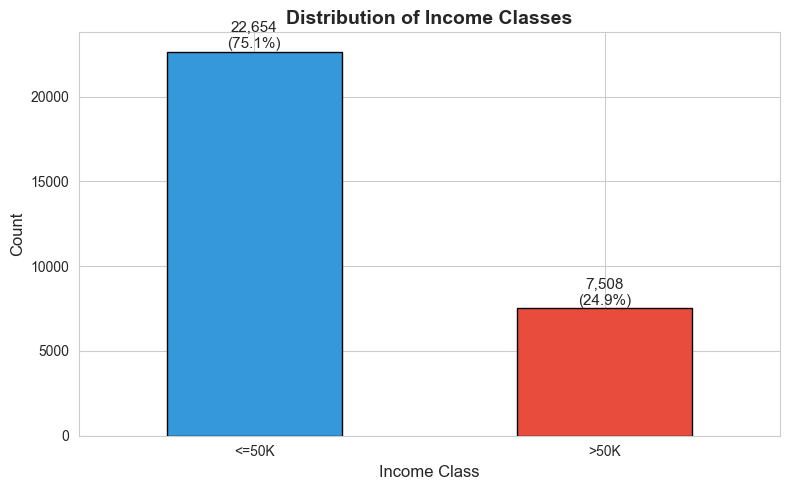

In [12]:
# Visualize income distribution
fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#3498db', '#e74c3c']
income_dist.plot(kind='bar', color=colors, ax=ax, edgecolor='black')
ax.set_title('Distribution of Income Classes', fontsize=14, fontweight='bold')
ax.set_xlabel('Income Class', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)

# Add count labels on bars
for i, (count, pct) in enumerate(zip(income_dist, income_pct)):
    ax.text(i, count + 200, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=11)

plt.tight_layout()
plt.show()

## 3. Distribution of Protected Attribute: Sex

In [5]:
# Sex distribution
sex_dist = data['sex'].value_counts()
sex_pct = data['sex'].value_counts(normalize=True) * 100

sex_table = pd.DataFrame({
    'Count': sex_dist,
    'Percentage (%)': sex_pct.round(2)
})
sex_table.index.name = 'Sex'

print("\n" + "=" * 60)
print("SEX DISTRIBUTION (Protected Attribute)")
print("=" * 60)
print(sex_table)
print(f"\nMale to Female Ratio: {sex_dist['Male']/sex_dist['Female']:.2f}:1")


SEX DISTRIBUTION (Protected Attribute)
        Count  Percentage (%)
Sex                          
Male    20380           67.57
Female   9782           32.43

Male to Female Ratio: 2.08:1


## 4. Distribution of Protected Attribute: Race

In [6]:
# Race distribution
race_dist = data['race'].value_counts()
race_pct = data['race'].value_counts(normalize=True) * 100

race_table = pd.DataFrame({
    'Count': race_dist,
    'Percentage (%)': race_pct.round(2)
})
race_table.index.name = 'Race'

print("\n" + "=" * 60)
print("RACE DISTRIBUTION (Protected Attribute)")
print("=" * 60)
print(race_table)


RACE DISTRIBUTION (Protected Attribute)
                    Count  Percentage (%)
Race                                     
White               25933           85.98
Black                2817            9.34
Asian-Pac-Islander    895            2.97
Amer-Indian-Eskimo    286            0.95
Other                 231            0.77


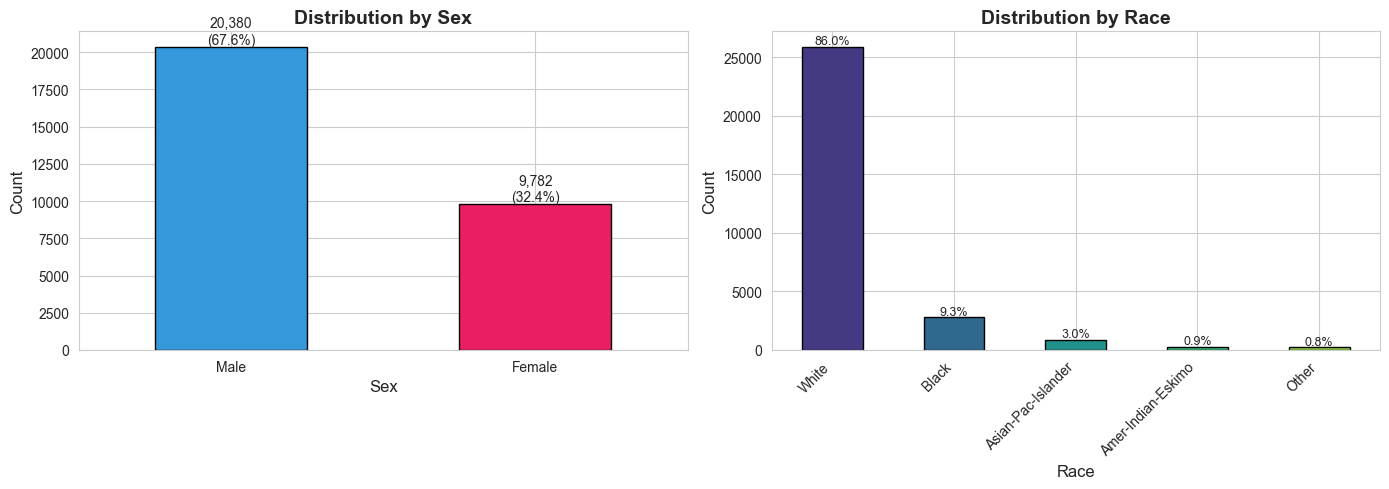

In [13]:
# Visualize Sex and Race distributions side by side
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sex distribution
colors_sex = ['#3498db', '#e91e63']
sex_dist.plot(kind='bar', ax=axes[0], color=colors_sex, edgecolor='black')
axes[0].set_title('Distribution by Sex', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sex', fontsize=12)
axes[0].set_ylabel('Count', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
for i, (count, pct) in enumerate(zip(sex_dist, sex_pct)):
    axes[0].text(i, count + 200, f'{count:,}\n({pct:.1f}%)', ha='center', fontsize=10)

# Race distribution
colors_race = sns.color_palette('viridis', len(race_dist))
race_dist.plot(kind='bar', ax=axes[1], color=colors_race, edgecolor='black')
axes[1].set_title('Distribution by Race', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Race', fontsize=12)
axes[1].set_ylabel('Count', fontsize=12)
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=45, ha='right')
for i, (count, pct) in enumerate(zip(race_dist, race_pct)):
    axes[1].text(i, count + 200, f'{pct:.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 5. Cross-Tabulation: Income Class by Sex
### This reveals potential data bias in income distribution across genders

In [7]:
# Cross-tabulation: Income by Sex
income_by_sex = pd.crosstab(data['sex'], data['income-class'], margins=True)
income_by_sex_pct = pd.crosstab(data['sex'], data['income-class'], normalize='index') * 100

print("\n" + "=" * 60)
print("CROSS-TABULATION: INCOME CLASS BY SEX")
print("=" * 60)
print("\nCounts:")
print(income_by_sex)
print("\nPercentages (within each sex group):")
print(income_by_sex_pct.round(2))


CROSS-TABULATION: INCOME CLASS BY SEX

Counts:
income-class  <=50K  >50K    All
sex                             
Female         8670  1112   9782
Male          13984  6396  20380
All           22654  7508  30162

Percentages (within each sex group):
income-class  <=50K   >50K
sex                       
Female        88.63  11.37
Male          68.62  31.38


In [8]:
# Create a detailed table for the report
sex_income_summary = pd.DataFrame({
    'Total': [sex_dist['Male'], sex_dist['Female']],
    '<=50K': income_by_sex.loc[['Male', 'Female'], '<=50K'].values,
    '<=50K (%)': income_by_sex_pct['<=50K'].values.round(1),
    '>50K': income_by_sex.loc[['Male', 'Female'], '>50K'].values,
    '>50K (%)': income_by_sex_pct['>50K'].values.round(1)
}, index=['Male', 'Female'])

print("\n" + "=" * 60)
print("SUMMARY TABLE: INCOME BY SEX (For Report)")
print("=" * 60)
print(sex_income_summary)
print(f"\n>>> KEY FINDING: Males are {income_by_sex_pct.loc['Male', '>50K']/income_by_sex_pct.loc['Female', '>50K']:.1f}x more likely to earn >50K than Females")


SUMMARY TABLE: INCOME BY SEX (For Report)
        Total  <=50K  <=50K (%)  >50K  >50K (%)
Male    20380  13984       88.6  6396      11.4
Female   9782   8670       68.6  1112      31.4

>>> KEY FINDING: Males are 2.8x more likely to earn >50K than Females


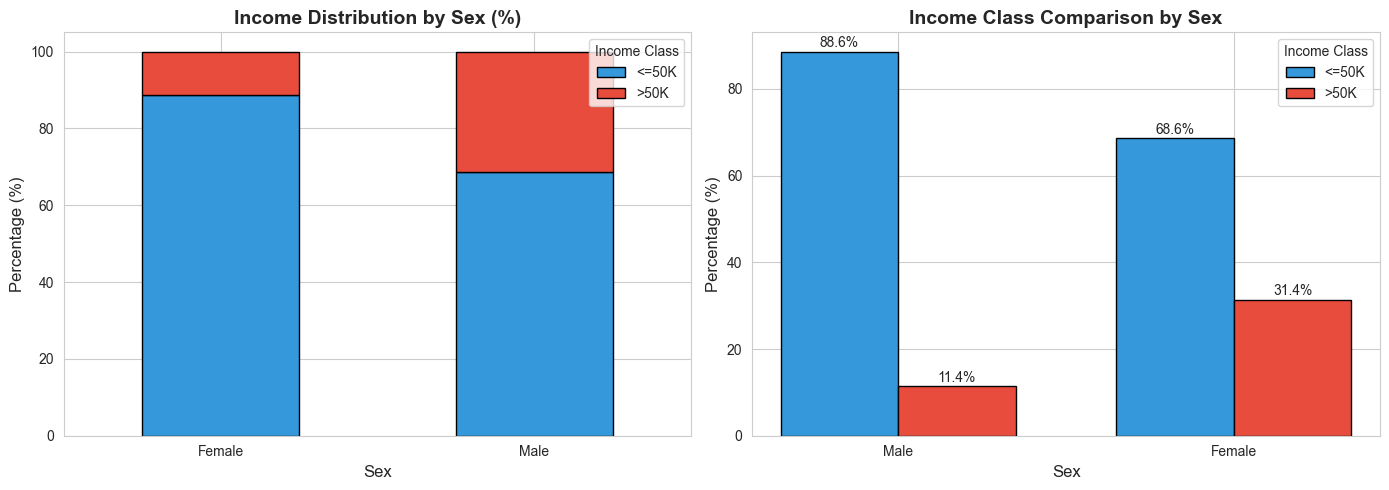

In [14]:
# Visualize Income by Sex
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Stacked bar chart
income_by_sex_pct.plot(kind='bar', stacked=True, ax=axes[0], 
                        color=['#3498db', '#e74c3c'], edgecolor='black')
axes[0].set_title('Income Distribution by Sex (%)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Sex', fontsize=12)
axes[0].set_ylabel('Percentage (%)', fontsize=12)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].legend(title='Income Class', loc='upper right')

# Grouped bar chart for comparison
x = np.arange(2)
width = 0.35
bars1 = axes[1].bar(x - width/2, income_by_sex_pct['<=50K'], width, label='<=50K', color='#3498db', edgecolor='black')
bars2 = axes[1].bar(x + width/2, income_by_sex_pct['>50K'], width, label='>50K', color='#e74c3c', edgecolor='black')
axes[1].set_title('Income Class Comparison by Sex', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Sex', fontsize=12)
axes[1].set_ylabel('Percentage (%)', fontsize=12)
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Male', 'Female'])
axes[1].legend(title='Income Class')

# Add value labels
for bar in bars1:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)
for bar in bars2:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
                 f'{bar.get_height():.1f}%', ha='center', fontsize=10)

plt.tight_layout()
plt.show()

## 6. Cross-Tabulation: Income Class by Race
### This reveals potential data bias in income distribution across racial groups

In [9]:
# Cross-tabulation: Income by Race
income_by_race = pd.crosstab(data['race'], data['income-class'], margins=True)
income_by_race_pct = pd.crosstab(data['race'], data['income-class'], normalize='index') * 100

print("\n" + "=" * 60)
print("CROSS-TABULATION: INCOME CLASS BY RACE")
print("=" * 60)
print("\nCounts:")
print(income_by_race)
print("\nPercentages (within each race group):")
print(income_by_race_pct.round(2))


CROSS-TABULATION: INCOME CLASS BY RACE

Counts:
income-class        <=50K  >50K    All
race                                  
Amer-Indian-Eskimo    252    34    286
Asian-Pac-Islander    647   248    895
Black                2451   366   2817
Other                 210    21    231
White               19094  6839  25933
All                 22654  7508  30162

Percentages (within each race group):
income-class        <=50K   >50K
race                            
Amer-Indian-Eskimo  88.11  11.89
Asian-Pac-Islander  72.29  27.71
Black               87.01  12.99
Other               90.91   9.09
White               73.63  26.37


In [10]:
# Create a detailed table for the report
race_income_summary = pd.DataFrame({
    'Total': race_dist.values,
    '<=50K': income_by_race.loc[race_dist.index, '<=50K'].values,
    '<=50K (%)': income_by_race_pct.loc[race_dist.index, '<=50K'].values.round(1),
    '>50K': income_by_race.loc[race_dist.index, '>50K'].values,
    '>50K (%)': income_by_race_pct.loc[race_dist.index, '>50K'].values.round(1)
}, index=race_dist.index)

print("\n" + "=" * 60)
print("SUMMARY TABLE: INCOME BY RACE (For Report)")
print("=" * 60)
print(race_income_summary)

# Find highest and lowest >50K rates
max_race = income_by_race_pct['>50K'].idxmax()
min_race = income_by_race_pct['>50K'].idxmin()
print(f"\n>>> KEY FINDING: {max_race} has highest >50K rate ({income_by_race_pct.loc[max_race, '>50K']:.1f}%)")
print(f">>> KEY FINDING: {min_race} has lowest >50K rate ({income_by_race_pct.loc[min_race, '>50K']:.1f}%)")


SUMMARY TABLE: INCOME BY RACE (For Report)
                    Total  <=50K  <=50K (%)  >50K  >50K (%)
Race                                                       
White               25933  19094       73.6  6839      26.4
Black                2817   2451       87.0   366      13.0
Asian-Pac-Islander    895    647       72.3   248      27.7
Amer-Indian-Eskimo    286    252       88.1    34      11.9
Other                 231    210       90.9    21       9.1

>>> KEY FINDING: Asian-Pac-Islander has highest >50K rate (27.7%)
>>> KEY FINDING: Other has lowest >50K rate (9.1%)


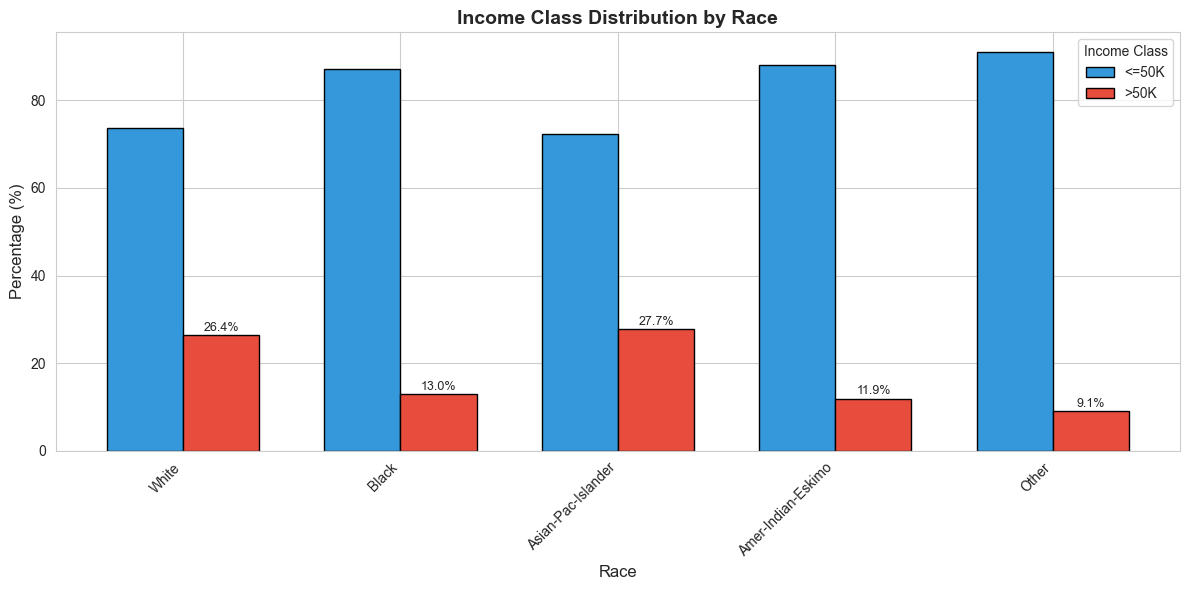

In [15]:
# Visualize Income by Race
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(len(race_dist))
width = 0.35

bars1 = ax.bar(x - width/2, income_by_race_pct.loc[race_dist.index, '<=50K'], 
               width, label='<=50K', color='#3498db', edgecolor='black')
bars2 = ax.bar(x + width/2, income_by_race_pct.loc[race_dist.index, '>50K'], 
               width, label='>50K', color='#e74c3c', edgecolor='black')

ax.set_title('Income Class Distribution by Race', fontsize=14, fontweight='bold')
ax.set_xlabel('Race', fontsize=12)
ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_xticks(x)
ax.set_xticklabels(race_dist.index, rotation=45, ha='right')
ax.legend(title='Income Class')

# Add value labels for >50K bars
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1, 
            f'{bar.get_height():.1f}%', ha='center', fontsize=9)

plt.tight_layout()
plt.show()

## 7. Summary: Key Data Bias Findings
### These findings support the "Cause of Unfairness" analysis

In [11]:
print("=" * 70)
print("SUMMARY: DATA BIAS FINDINGS FOR 'CAUSE OF UNFAIRNESS' ANALYSIS")
print("=" * 70)

print("\n1. CLASS IMBALANCE:")
print(f"   - The dataset is heavily skewed toward <=50K ({income_pct['<=50K']:.1f}% vs {income_pct['>50K']:.1f}%)")
print(f"   - Ratio: {income_dist['<=50K']/income_dist['>50K']:.2f}:1")

print("\n2. SEX IMBALANCE:")
print(f"   - Males dominate the dataset ({sex_pct['Male']:.1f}% vs {sex_pct['Female']:.1f}%)")
print(f"   - Male >50K rate: {income_by_sex_pct.loc['Male', '>50K']:.1f}%")
print(f"   - Female >50K rate: {income_by_sex_pct.loc['Female', '>50K']:.1f}%")
print(f"   - Gap: {income_by_sex_pct.loc['Male', '>50K'] - income_by_sex_pct.loc['Female', '>50K']:.1f} percentage points")

print("\n3. RACE IMBALANCE:")
print(f"   - White individuals dominate ({race_pct['White']:.1f}% of dataset)")
print(f"   - Highest >50K rate: {max_race} ({income_by_race_pct.loc[max_race, '>50K']:.1f}%)")
print(f"   - Lowest >50K rate: {min_race} ({income_by_race_pct.loc[min_race, '>50K']:.1f}%)")
print(f"   - Gap between highest and lowest: {income_by_race_pct['>50K'].max() - income_by_race_pct['>50K'].min():.1f} percentage points")

print("\n" + "=" * 70)
print("IMPLICATION: The classifier may inherit these biases from the data,")
print("potentially leading to unfair predictions for underrepresented groups.")
print("=" * 70)

SUMMARY: DATA BIAS FINDINGS FOR 'CAUSE OF UNFAIRNESS' ANALYSIS

1. CLASS IMBALANCE:
   - The dataset is heavily skewed toward <=50K (75.1% vs 24.9%)
   - Ratio: 3.02:1

2. SEX IMBALANCE:
   - Males dominate the dataset (67.6% vs 32.4%)
   - Male >50K rate: 31.4%
   - Female >50K rate: 11.4%
   - Gap: 20.0 percentage points

3. RACE IMBALANCE:
   - White individuals dominate (86.0% of dataset)
   - Highest >50K rate: Asian-Pac-Islander (27.7%)
   - Lowest >50K rate: Other (9.1%)
   - Gap between highest and lowest: 18.6 percentage points

IMPLICATION: The classifier may inherit these biases from the data,
potentially leading to unfair predictions for underrepresented groups.
